In [30]:
# ============================================================
# VAW ANALYTICS SYSTEM — BANGLADESH
# ============================================================
# Project   : Predicting IPV Tolerance Using ML
# Data      : Bangladesh DHS 2022 (BBS & UNFPA)
# Author    : Shoibal Das
# Purpose   : MSc Application Portfolio Project
# ============================================================
#
# Notebooks structure:
# This notebook covers:
#   1. Data Loading
#   2. Exploratory Data Analysis (EDA)
#   3. Target Variable Creation
#   4. ML Model Training (LR, RF, XGBoost)
#   5. SHAP Feature Importance Analysis
#   6. Division-wise Risk Map
#   7. Summary Findings
# ============================================================

In [2]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import warnings

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 50)
plt.style.use('seaborn-v0_8')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# List all files in data/raw folder
for file in os.listdir("data/raw"):
    print(file)

BDGC7RFL
BDGC81FL
BDGE7SFL
BDGE81FL
BDIR7RDT
BDIR81DT


In [4]:
for root, dirs, files in os.walk("data/raw"):
    for file in files:
        print(os.path.join(root, file))

data/raw\BDGC7RFL\BDGC7RFL\BDGC7RFL.csv
data/raw\BDGC7RFL\BDGC7RFL\DHS Covariates Extract Data Description_3.pdf
data/raw\BDGC81FL\BDGC81FL.csv
data/raw\BDGC81FL\DHS Covariates Extract Data Description_3.pdf
data/raw\BDGE7SFL\BDGE7SFL.cpg
data/raw\BDGE7SFL\BDGE7SFL.dbf
data/raw\BDGE7SFL\BDGE7SFL.prj
data/raw\BDGE7SFL\BDGE7SFL.sbn
data/raw\BDGE7SFL\BDGE7SFL.sbx
data/raw\BDGE7SFL\BDGE7SFL.shp
data/raw\BDGE7SFL\BDGE7SFL.shp.xml
data/raw\BDGE7SFL\BDGE7SFL.shx
data/raw\BDGE7SFL\Data_Alert_README.txt
data/raw\BDGE7SFL\DHS_README.txt
data/raw\BDGE7SFL\GPS_Displacement_README.txt
data/raw\BDGE81FL\BDGE81FL.cpg
data/raw\BDGE81FL\BDGE81FL.dbf
data/raw\BDGE81FL\BDGE81FL.prj
data/raw\BDGE81FL\BDGE81FL.sbn
data/raw\BDGE81FL\BDGE81FL.sbx
data/raw\BDGE81FL\BDGE81FL.shp
data/raw\BDGE81FL\BDGE81FL.shp.xml
data/raw\BDGE81FL\BDGE81FL.shx
data/raw\BDGE81FL\DHS_README.txt
data/raw\BDGE81FL\GPS_Displacement_README.txt
data/raw\BDIR7RDT\BDIR7RFL.DCT
data/raw\BDIR7RDT\BDIR7RFL.DO
data/raw\BDIR7RDT\BDIR7RFL.DO

In [5]:
# Load DHS 2022 Women's Individual Recode dataset
DATA_PATH = "data/raw/BDIR81DT/BDIR81FL.DTA"

df = pd.read_stata(DATA_PATH, convert_categoricals=False)
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Shape: 30078 rows × 5425 columns

First 5 rows:


,caseid,v000,v001,v002,v003,v004,v005,v006,v007,v008,v008a,v009,v010,v011,v012,v013,v014,v015,v016,v017,v018,v019,v019a,v020,v021,v022,v023,v024,v025,v026,v027,v028,v029,v030,v031,v032,v034,v040,v042,v044,v045a,v045b,v045c,v046,v047,v048,v101,v102,v103,v104,...,idx96_5,idx96_6,s612i_1,s612i_2,s612i_3,s612i_4,s612i_5,s612i_6,s612k_1,s612k_2,s612k_3,s612k_4,s612k_5,s612k_6,s612w_1,s612w_2,s612w_3,s612w_4,s612w_5,s612w_6,s626i_1,s626i_2,s626i_3,s626i_4,s626i_5,s626i_6,s626k_1,s626k_2,s626k_3,s626k_4,s626k_5,s626k_6,s626w_1,s626w_2,s626w_3,s626w_4,s626w_5,s626w_6,s631j_1,s631j_2,s631j_3,s631j_4,s631j_5,s631j_6,s631k_1,s631k_2,s631k_3,s631k_4,s631k_5,s631k_6
0,1 1 3,BD8,1,1,3,1,156207,9,2022,1473,44817,8,1976,920,46,7,1,1,13,1405.0,12.0,69.0,2.0,1,1,1,1,1,1,0,1,604,NaN,600,NaN,NaN,NaN,9,NaN,NaN,2,2,2,0,6,600,1,1,NaN,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 4 2,BD8,1,4,2,1,156207,9,2022,1473,44817,8,1973,884,49,7,6,1,13,1405.0,12.0,69.0,2.0,1,1,1,1,1,1,0,1,604,NaN,600,NaN,NaN,NaN,9,NaN,NaN,2,2,2,0,6,600,1,1,NaN,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1 7 3,BD8,1,7,3,1,156207,9,2022,1473,44817,7,1995,1147,27,3,1,1,13,NaN,NaN,NaN,NaN,1,1,1,1,1,1,0,1,604,NaN,600,NaN,NaN,NaN,9,NaN,NaN,2,2,2,0,6,600,1,1,NaN,95,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1 10 2,BD8,1,10,2,1,156207,9,2022,1473,44817,12,1981,984,40,6,2,1,13,1405.0,12.0,69.0,2.0,1,1,1,1,1,1,0,1,604,NaN,600,NaN,NaN,NaN,9,NaN,NaN,2,2,2,0,6,600,1,1,NaN,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1 13 2,BD8,1,13,2,1,156207,9,2022,1473,44818,3,1973,879,49,7,2,1,14,1405.0,12.0,69.0,2.0,1,1,1,1,1,1,0,1,604,NaN,600,NaN,NaN,NaN,9,NaN,NaN,2,2,2,0,6,600,1,1,NaN,37,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Check basic dataset info
print(f"Dataset Shape: {df.shape}")
print(f"\nColumn names (first 50):")
print(df.columns[:50].tolist())

print(f"\nLooking for domestic violence columns (d- variables):")
dv_cols = [col for col in df.columns if col.startswith('d')]
print(f"Found {len(dv_cols)} domestic violence related columns:")
print(dv_cols)

Dataset Shape: (30078, 5425)

Column names (first 50):
['caseid', 'v000', 'v001', 'v002', 'v003', 'v004', 'v005', 'v006', 'v007', 'v008', 'v008a', 'v009', 'v010', 'v011', 'v012', 'v013', 'v014', 'v015', 'v016', 'v017', 'v018', 'v019', 'v019a', 'v020', 'v021', 'v022', 'v023', 'v024', 'v025', 'v026', 'v027', 'v028', 'v029', 'v030', 'v031', 'v032', 'v034', 'v040', 'v042', 'v044', 'v045a', 'v045b', 'v045c', 'v046', 'v047', 'v048', 'v101', 'v102', 'v103', 'v104']

Looking for domestic violence columns (d- variables):
Found 0 domestic violence related columns:
[]


In [7]:
# Search more broadly for violence-related columns
print("Searching all column patterns...\n")

# Check columns starting with different letters
for prefix in ['d', 'D', 'v7', 'v8', 'v9', 'dv', 'w6']:
    cols = [col for col in df.columns if col.startswith(prefix)]
    if cols:
        print(f"Prefix '{prefix}': {len(cols)} columns → {cols[:5]}")

# Also search for any column containing specific numbers
print("\nColumns from v700 onwards (likely domestic violence section):")
late_cols = [col for col in df.columns if col.startswith('v7') or 
             col.startswith('v8') or col.startswith('v9')]
print(f"Found: {len(late_cols)} columns")
print(late_cols[:30])

Searching all column patterns...

Prefix 'v7': 143 columns → ['v701', 'v702', 'v704', 'v704a', 'v705']
Prefix 'v8': 86 columns → ['v820', 'v821a', 'v821b', 'v821c', 'v822']

Columns from v700 onwards (likely domestic violence section):
Found: 229 columns
['v701', 'v702', 'v704', 'v704a', 'v705', 'v714', 'v714a', 'v715', 'v716', 'v717', 'v719', 'v721', 'v729', 'v730', 'v731', 'v732', 'v739', 'v740', 'v741', 'v743a', 'v743b', 'v743c', 'v743d', 'v743e', 'v743f', 'v744a', 'v744b', 'v744c', 'v744d', 'v744e']


In [8]:
# Print all v744 and v743 columns - these are key IPV attitude variables
print("Wife beating attitude variables (v744):")
v744_cols = [col for col in df.columns if col.startswith('v744')]
print(v744_cols)
print(df[v744_cols].head())

print("\nDecision making variables (v743):")
v743_cols = [col for col in df.columns if col.startswith('v743')]
print(v743_cols)

print("\nAll v8xx columns (domestic violence experience):")
v8_cols = [col for col in df.columns if col.startswith('v8')]
print(f"Total: {len(v8_cols)}")
print(v8_cols)

print("\nChecking for d1xx columns specifically:")
d1_cols = [col for col in df.columns if col.startswith('d1')]
print(f"Found: {len(d1_cols)}")
print(d1_cols[:20])

Wife beating attitude variables (v744):
['v744a', 'v744b', 'v744c', 'v744d', 'v744e']
   v744a  v744b  v744c  v744d  v744e
0    0.0    0.0    0.0    0.0    0.0
1    0.0    0.0    0.0    0.0    0.0
2    NaN    NaN    NaN    NaN    NaN
3    0.0    0.0    0.0    0.0    0.0
4    0.0    0.0    0.0    0.0    0.0

Decision making variables (v743):
['v743a', 'v743b', 'v743c', 'v743d', 'v743e', 'v743f']

All v8xx columns (domestic violence experience):
Total: 86
['v820', 'v821a', 'v821b', 'v821c', 'v822', 'v823', 'v824', 'v825', 'v826', 'v826a', 'v827', 'v828', 'v829', 'v830', 'v831', 'v832b', 'v832c', 'v833a', 'v833b', 'v833c', 'v834a', 'v834b', 'v834c', 'v835a', 'v835b', 'v835c', 'v836', 'v837', 'v838a', 'v838b', 'v838c', 'v839', 'v839a', 'v840', 'v840a', 'v841', 'v841a', 'v842', 'v843', 'v850a', 'v850b', 'v852a', 'v852b', 'v852c', 'v853a', 'v853b', 'v853c', 'v855', 'v856', 'v857a', 'v857b', 'v857c', 'v857d', 'v858', 'v859', 'v860m', 'v860y', 'v860c', 'v861', 'v862m', 'v862y', 'v862c', 'v863'

In [9]:
# Map key variables for our analysis
key_vars = {
    # Respondent characteristics
    'v012': 'age',
    'v024': 'division',
    'v025': 'residence',        # urban/rural
    'v106': 'education_level',
    'v190': 'wealth_index',
    'v714': 'employed',
    'v501': 'marital_status',
    
    # Husband/partner characteristics  
    'v701': 'husband_education',
    'v730': 'husband_age',
    
    # Attitude variables (wife beating justified)
    'v744a': 'beat_justified_goes_out',
    'v744b': 'beat_justified_neglects_children',
    'v744c': 'beat_justified_argues',
    'v744d': 'beat_justified_refuses_sex',
    'v744e': 'beat_justified_burns_food',
    
    # IPV experience variables
    'v820': 'physical_violence_ever',
    'v821a': 'violence_perpetrator_1',
    'v822': 'physical_violence_12months',
}

# Check which of these exist in our dataset
print("Available key variables:")
available = {}
for var, label in key_vars.items():
    if var in df.columns:
        print(f"  {var} → {label}")
        available[var] = label
    else:
        print(f" {var} → {label} NOT FOUND")

print(f"\nSample values for v820 (physical violence ever):")
if 'v820' in df.columns:
    print(df['v820'].value_counts())

Available key variables:
  v012 → age
  v024 → division
  v025 → residence
  v106 → education_level
  v190 → wealth_index
  v714 → employed
  v501 → marital_status
  v701 → husband_education
  v730 → husband_age
  v744a → beat_justified_goes_out
  v744b → beat_justified_neglects_children
  v744c → beat_justified_argues
  v744d → beat_justified_refuses_sex
  v744e → beat_justified_burns_food
  v820 → physical_violence_ever
  v821a → violence_perpetrator_1
  v822 → physical_violence_12months

Sample values for v820 (physical violence ever):
Series([], Name: count, dtype: int64)


In [10]:
# Check v820 in detail including NaN values
print("v820 - Physical violence ever:")
print(f"Total rows: {len(df['v820'])}")
print(f"Non-null values: {df['v820'].notna().sum()}")
print(f"Null values: {df['v820'].isna().sum()}")
print(f"\nUnique values: {df['v820'].unique()}")
print(f"\nValue counts including NaN:")
print(df['v820'].value_counts(dropna=False))

# Check v822 as well
print("\n\nv822 - Physical violence last 12 months:")
print(f"Non-null values: {df['v822'].notna().sum()}")
print(df['v822'].value_counts(dropna=False))

v820 - Physical violence ever:
Total rows: 30078
Non-null values: 0
Null values: 30078

Unique values: [nan]

Value counts including NaN:
v820
NaN    30078
Name: count, dtype: int64


v822 - Physical violence last 12 months:
Non-null values: 0
v822
NaN    30078
Name: count, dtype: int64


In [11]:
# Check 1: Are attitude variables (v744) available?
print("Wife beating attitude variables:")
print(df[['v744a','v744b','v744c','v744d','v744e']].value_counts(dropna=False).head(10))

# Check 2: Is there a domestic violence selection variable?
print("\nv044 - Selected for DV module:")
if 'v044' in df.columns:
    print(df['v044'].value_counts(dropna=False))
else:
    print("v044 not found")

# Check 3: How many v8xx columns have actual data?
print("\nv8xx columns with non-null data:")
v8_cols = [col for col in df.columns if col.startswith('v8')]
for col in v8_cols:
    non_null = df[col].notna().sum()
    if non_null > 0:
        print(f"  {col}: {non_null} non-null values")

Wife beating attitude variables:
v744a  v744b  v744c  v744d  v744e
0.0    0.0    0.0    0.0    0.0      17047
NaN    NaN    NaN    NaN    NaN      10091
0.0    0.0    1.0    0.0    0.0        553
       1.0    0.0    0.0    0.0        341
1.0    0.0    0.0    0.0    0.0        256
0.0    1.0    1.0    0.0    0.0        254
1.0    1.0    1.0    0.0    0.0        242
                     1.0    0.0        156
8.0    0.0    0.0    0.0    0.0        154
1.0    1.0    1.0    1.0    1.0        123
Name: count, dtype: int64

v044 - Selected for DV module:
v044
NaN    30078
Name: count, dtype: int64

v8xx columns with non-null data:
  v801: 30078 non-null values
  v802: 30078 non-null values
  v803: 30078 non-null values
  v804: 30078 non-null values
  v805: 30078 non-null values
  v811: 19987 non-null values
  v812: 19987 non-null values
  v813: 19987 non-null values
  v814: 19987 non-null values


In [12]:
print("All files in data/raw:")
for root, dirs, files in os.walk("data/raw"):
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath) / (1024*1024)
        print(f"  {filepath} ({size:.1f} MB)")

All files in data/raw:
  data/raw\BDGC7RFL\BDGC7RFL\BDGC7RFL.csv (0.9 MB)
  data/raw\BDGC7RFL\BDGC7RFL\DHS Covariates Extract Data Description_3.pdf (0.5 MB)
  data/raw\BDGC81FL\BDGC81FL.csv (0.9 MB)
  data/raw\BDGC81FL\DHS Covariates Extract Data Description_3.pdf (0.5 MB)
  data/raw\BDGE7SFL\BDGE7SFL.cpg (0.0 MB)
  data/raw\BDGE7SFL\BDGE7SFL.dbf (2.0 MB)
  data/raw\BDGE7SFL\BDGE7SFL.prj (0.0 MB)
  data/raw\BDGE7SFL\BDGE7SFL.sbn (0.0 MB)
  data/raw\BDGE7SFL\BDGE7SFL.sbx (0.0 MB)
  data/raw\BDGE7SFL\BDGE7SFL.shp (0.0 MB)
  data/raw\BDGE7SFL\BDGE7SFL.shp.xml (0.0 MB)
  data/raw\BDGE7SFL\BDGE7SFL.shx (0.0 MB)
  data/raw\BDGE7SFL\Data_Alert_README.txt (0.0 MB)
  data/raw\BDGE7SFL\DHS_README.txt (0.0 MB)
  data/raw\BDGE7SFL\GPS_Displacement_README.txt (0.0 MB)
  data/raw\BDGE81FL\BDGE81FL.cpg (0.0 MB)
  data/raw\BDGE81FL\BDGE81FL.dbf (2.1 MB)
  data/raw\BDGE81FL\BDGE81FL.prj (0.0 MB)
  data/raw\BDGE81FL\BDGE81FL.sbn (0.0 MB)
  data/raw\BDGE81FL\BDGE81FL.sbx (0.0 MB)
  data/raw\BDGE81FL\BDG

In [13]:
# Build IPV Tolerance target variable from v744a-v744e (2022 dataset)
print("Wife Beating Attitude Variables — DHS 2022")
print("="*50)
print("0 = Not justified | 1 = Justified | 8 = Don't know\n")

attitude_cols = ['v744a', 'v744b', 'v744c', 'v744d', 'v744e']
labels = [
    'Goes out without telling',
    'Neglects children',
    'Argues with husband',
    'Refuses sex',
    'Burns food'
]

for col, label in zip(attitude_cols, labels):
    counts = df[col].value_counts(dropna=False)
    print(f"{col} — {label}:")
    print(counts)
    print()

Wife Beating Attitude Variables — DHS 2022
0 = Not justified | 1 = Justified | 8 = Don't know

v744a — Goes out without telling:
v744a
0.0    18682
NaN    10091
1.0     1095
8.0      210
Name: count, dtype: int64

v744b — Neglects children:
v744b
0.0    18520
NaN    10091
1.0     1395
8.0       72
Name: count, dtype: int64

v744c — Argues with husband:
v744c
0.0    18226
NaN    10091
1.0     1681
8.0       80
Name: count, dtype: int64

v744d — Refuses sex:
v744d
0.0    19320
NaN    10091
1.0      603
8.0       64
Name: count, dtype: int64

v744e — Burns food:
v744e
0.0    19650
NaN    10091
1.0      279
8.0       58
Name: count, dtype: int64



In [14]:
# Create IPV Tolerance target variable
# 1 = accepts wife beating for ANY reason, 0 = never accepts

# Work with non-null rows only
df_clean = df.dropna(subset=attitude_cols).copy()

# Replace 8 (don't know) with NaN then drop
df_clean[attitude_cols] = df_clean[attitude_cols].replace(8.0, np.nan)
df_clean = df_clean.dropna(subset=attitude_cols)

# Create binary target: 1 if justified for ANY reason
df_clean['ipv_tolerance'] = (
    df_clean[attitude_cols].sum(axis=1) > 0
).astype(int)

print(f"Target variable created!")
print(f"Working dataset: {df_clean.shape[0]} women")
print(f"\nIPV Tolerance Distribution:")
print(df_clean['ipv_tolerance'].value_counts())
print(f"\nPercentage accepting wife beating:")
pct = df_clean['ipv_tolerance'].mean() * 100
print(f"  {pct:.1f}% of women accept wife beating for at least one reason")

Target variable created!
Working dataset: 19606 women

IPV Tolerance Distribution:
ipv_tolerance
0    17047
1     2559
Name: count, dtype: int64

Percentage accepting wife beating:
  13.1% of women accept wife beating for at least one reason


In [15]:
# Define feature columns
feature_cols = ['v012', 'v024', 'v025', 'v106', 'v190', 
                'v714', 'v501', 'v701', 'v730']

feature_labels = {
    'v012': 'Age',
    'v024': 'Division',
    'v025': 'Residence (Urban/Rural)',
    'v106': 'Education Level',
    'v190': 'Wealth Index',
    'v714': 'Employed',
    'v501': 'Marital Status',
    'v701': 'Husband Education',
    'v730': 'Husband Age'
}

# Check missing values
print("Feature Overview:")
print(f"{'Variable':<8} {'Label':<25} {'Non-Null':<10} {'Missing %':<10} {'Unique Values'}")
print("="*75)
for col in feature_cols:
    if col in df_clean.columns:
        non_null = df_clean[col].notna().sum()
        missing_pct = (df_clean[col].isna().sum() / len(df_clean)) * 100
        unique = df_clean[col].nunique()
        print(f"{col:<8} {feature_labels[col]:<25} {non_null:<10} {missing_pct:<10.1f} {unique}")

Feature Overview:
Variable Label                     Non-Null   Missing %  Unique Values
v012     Age                       19606      0.0        35
v024     Division                  19606      0.0        8
v025     Residence (Urban/Rural)   19606      0.0        2
v106     Education Level           19606      0.0        4
v190     Wealth Index              19606      0.0        5
v714     Employed                  19606      0.0        2
v501     Marital Status            19606      0.0        4
v701     Husband Education         18632      5.0        5
v730     Husband Age               18632      5.0        67


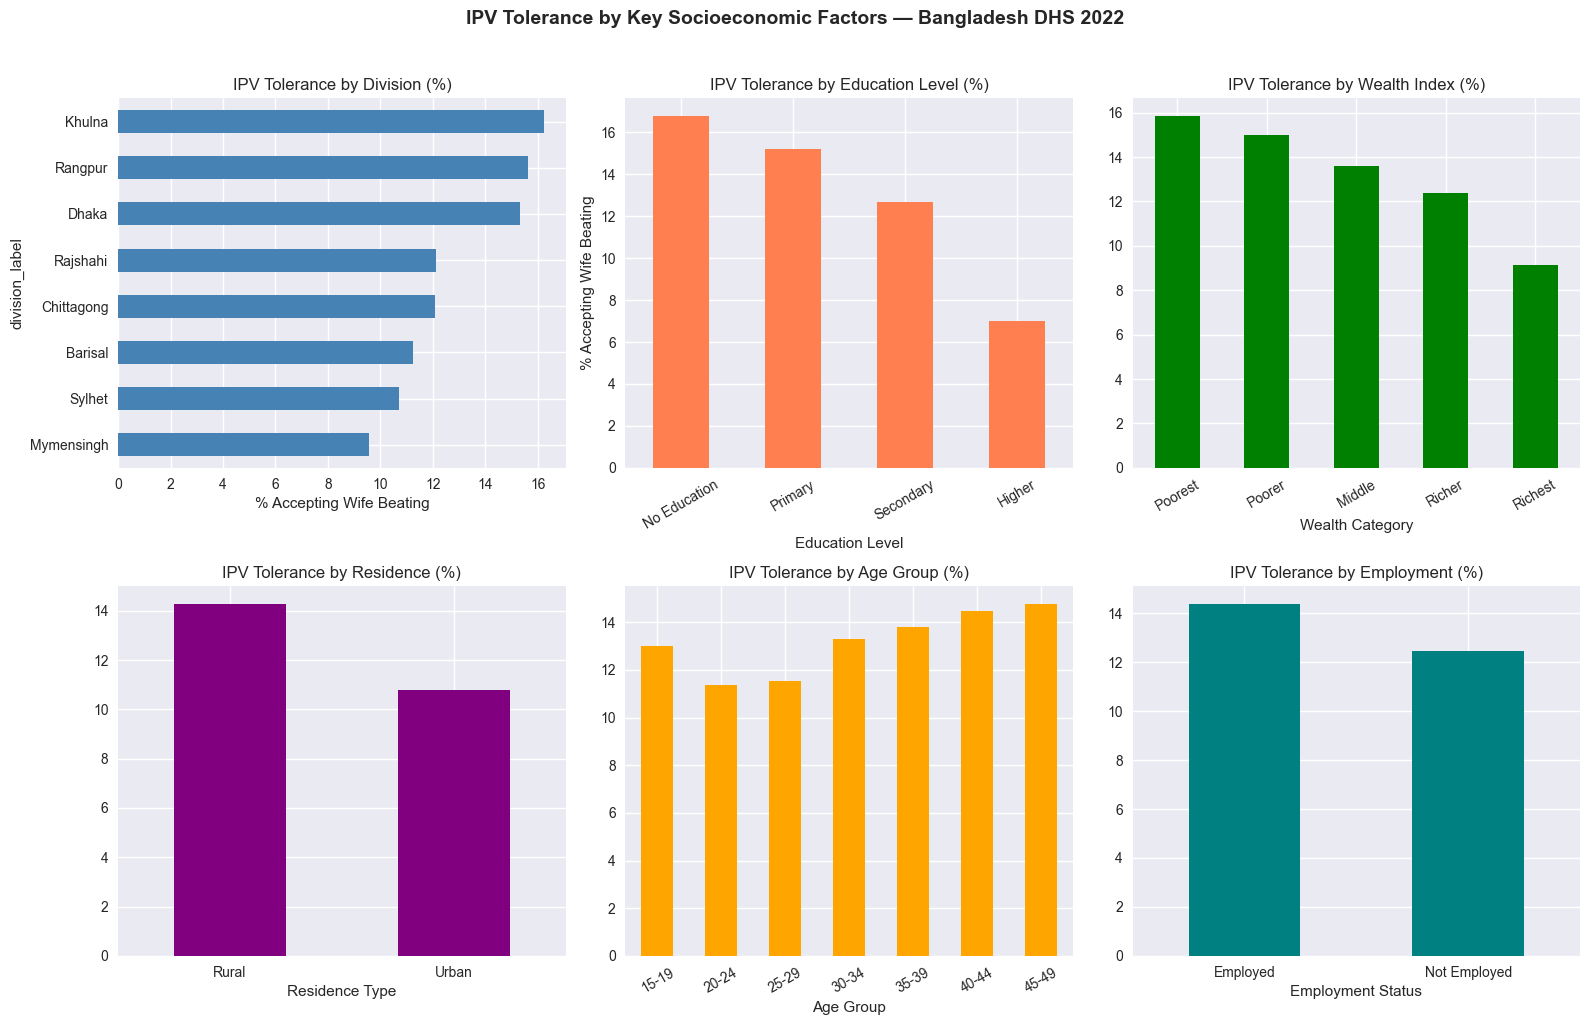

Chart saved to reports/figures/


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('IPV Tolerance by Key Socioeconomic Factors — Bangladesh DHS 2022', 
             fontsize=14, fontweight='bold', y=1.02)

# Division mapping
division_map = {1:'Barisal', 2:'Chittagong', 3:'Dhaka', 4:'Khulna', 
                5:'Rajshahi', 6:'Rangpur', 7:'Sylhet', 8:'Mymensingh'}
education_map = {0:'No Education', 1:'Primary', 2:'Secondary', 3:'Higher'}
residence_map = {1:'Urban', 2:'Rural'}
wealth_map = {1:'Poorest', 2:'Poorer', 3:'Middle', 4:'Richer', 5:'Richest'}

df_plot = df_clean.copy()
df_plot['division_label'] = df_plot['v024'].map(division_map)
df_plot['education_label'] = df_plot['v106'].map(education_map)
df_plot['residence_label'] = df_plot['v025'].map(residence_map)
df_plot['wealth_label'] = df_plot['v190'].map(wealth_map)

# Plot 1: IPV tolerance by Division
ax1 = axes[0, 0]
div_data = df_plot.groupby('division_label')['ipv_tolerance'].mean() * 100
div_data.sort_values(ascending=True).plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title('IPV Tolerance by Division (%)')
ax1.set_xlabel('% Accepting Wife Beating')

# Plot 2: By Education
ax2 = axes[0, 1]
edu_data = df_plot.groupby('education_label')['ipv_tolerance'].mean() * 100
edu_order = ['No Education', 'Primary', 'Secondary', 'Higher']
edu_data.reindex(edu_order).plot(kind='bar', ax=ax2, color='coral')
ax2.set_title('IPV Tolerance by Education Level (%)')
ax2.set_xlabel('Education Level')
ax2.set_ylabel('% Accepting Wife Beating')
ax2.tick_params(axis='x', rotation=30)

# Plot 3: By Wealth Index
ax3 = axes[0, 2]
wealth_data = df_plot.groupby('wealth_label')['ipv_tolerance'].mean() * 100
wealth_order = ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']
wealth_data.reindex(wealth_order).plot(kind='bar', ax=ax3, color='green')
ax3.set_title('IPV Tolerance by Wealth Index (%)')
ax3.set_xlabel('Wealth Category')
ax3.tick_params(axis='x', rotation=30)

# Plot 4: By Residence
ax4 = axes[1, 0]
res_data = df_plot.groupby('residence_label')['ipv_tolerance'].mean() * 100
res_data.plot(kind='bar', ax=ax4, color='purple')
ax4.set_title('IPV Tolerance by Residence (%)')
ax4.set_xlabel('Residence Type')
ax4.tick_params(axis='x', rotation=0)

# Plot 5: By Age Group
ax5 = axes[1, 1]
df_plot['age_group'] = pd.cut(df_plot['v012'], 
                               bins=[14,19,24,29,34,39,44,49],
                               labels=['15-19','20-24','25-29','30-34','35-39','40-44','45-49'])
age_data = df_plot.groupby('age_group', observed=True)['ipv_tolerance'].mean() * 100
age_data.plot(kind='bar', ax=ax5, color='orange')
ax5.set_title('IPV Tolerance by Age Group (%)')
ax5.set_xlabel('Age Group')
ax5.tick_params(axis='x', rotation=30)

# Plot 6: By Employment
ax6 = axes[1, 2]
emp_map = {0: 'Not Employed', 1: 'Employed'}
df_plot['employment_label'] = df_plot['v714'].map(emp_map)
emp_data = df_plot.groupby('employment_label')['ipv_tolerance'].mean() * 100
emp_data.plot(kind='bar', ax=ax6, color='teal')
ax6.set_title('IPV Tolerance by Employment (%)')
ax6.set_xlabel('Employment Status')
ax6.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('reports/figures/ipv_tolerance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/figures/")

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb

# Prepare features and target
feature_cols = ['v012', 'v024', 'v025', 'v106', 'v190', 'v714', 'v501']
X = df_clean[feature_cols].copy()
y = df_clean['ipv_tolerance'].copy()

# Add age group as feature
X['age_group_num'] = pd.cut(df_clean['v012'], 
                             bins=[14,19,24,29,34,39,44,49],
                             labels=[1,2,3,4,5,6,7]).astype(float)

# Drop any remaining nulls
X = X.dropna()
y = y[X.index]

print(f"Features prepared")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nClass imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1")

Features prepared
X shape: (19606, 8)
y shape: (19606,)

Class distribution:
ipv_tolerance
0    17047
1     2559
Name: count, dtype: int64

Class imbalance ratio: 6.7:1


In [18]:
# Split data and apply SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"\nBefore SMOTE:")
print(f"  Class 0: {y_train.value_counts()[0]} | Class 1: {y_train.value_counts()[1]}")

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Class 0: {y_train_sm.value_counts()[0]} | Class 1: {y_train_sm.value_counts()[1]}")
print(f"  Total training samples: {len(X_train_sm)}")
print(f"\nData ready for model training!")

Train size: 15684 | Test size: 3922

Before SMOTE:
  Class 0: 13637 | Class 1: 2047

After SMOTE:
  Class 0: 13637 | Class 1: 13637
  Total training samples: 27274

Data ready for model training!


In [19]:
from sklearn.metrics import classification_report, roc_auc_score

# Train all three models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train_sm, y_train_sm)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Score
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'auc': auc, 'y_pred': y_pred}
    
    print(f"{name} — AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Tolerance', 'IPV Tolerance']))
    print("="*60)

Training Logistic Regression...
Logistic Regression — AUC: 0.5677
               precision    recall  f1-score   support

 No Tolerance       0.89      0.62      0.73      3410
IPV Tolerance       0.16      0.47      0.24       512

     accuracy                           0.60      3922
    macro avg       0.52      0.55      0.48      3922
 weighted avg       0.79      0.60      0.66      3922

Training Random Forest...
Random Forest — AUC: 0.5358
               precision    recall  f1-score   support

 No Tolerance       0.87      0.78      0.83      3410
IPV Tolerance       0.14      0.24      0.18       512

     accuracy                           0.71      3922
    macro avg       0.51      0.51      0.50      3922
 weighted avg       0.78      0.71      0.74      3922

Training XGBoost...
XGBoost — AUC: 0.5550
               precision    recall  f1-score   support

 No Tolerance       0.88      0.73      0.80      3410
IPV Tolerance       0.15      0.32      0.20       512

     

In [20]:
# Add more features to improve model performance
feature_cols_v2 = [
    'v012',  # age
    'v024',  # division
    'v025',  # residence
    'v106',  # education
    'v190',  # wealth
    'v714',  # employed
    'v501',  # marital status
    'v701',  # husband education
    'v730',  # husband age
    'v743a', # woman decides own healthcare
    'v743b', # woman decides large purchases
    'v743d', # woman decides visits to family
]

X2 = df_clean[feature_cols_v2].copy()
y2 = df_clean['ipv_tolerance'].copy()

# Fill missing husband data with median
X2['v701'] = X2['v701'].fillna(X2['v701'].median())
X2['v730'] = X2['v730'].fillna(X2['v730'].median())
X2['v743a'] = X2['v743a'].fillna(X2['v743a'].median())
X2['v743b'] = X2['v743b'].fillna(X2['v743b'].median())
X2['v743d'] = X2['v743d'].fillna(X2['v743d'].median())

X2 = X2.dropna()
y2 = y2[X2.index]

# Split and SMOTE
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
X2_train_sm, y2_train_sm = smote.fit_resample(X2_train, y2_train)

# Train XGBoost with more features
print("Training XGBoost with expanded features...")
xgb_v2 = xgb.XGBClassifier(
    random_state=42, 
    eval_metric='logloss', 
    verbosity=0,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05
)
xgb_v2.fit(X2_train_sm, y2_train_sm)
y2_pred = xgb_v2.predict(X2_test)
y2_prob = xgb_v2.predict_proba(X2_test)[:, 1]
auc_v2 = roc_auc_score(y2_test, y2_prob)

print(f"XGBoost v2 — AUC: {auc_v2:.4f}")
print(classification_report(y2_test, y2_pred, 
      target_names=['No Tolerance', 'IPV Tolerance']))

Training XGBoost with expanded features...
XGBoost v2 — AUC: 0.5651
               precision    recall  f1-score   support

 No Tolerance       0.87      0.99      0.93      3410
IPV Tolerance       0.24      0.03      0.05       512

     accuracy                           0.86      3922
    macro avg       0.56      0.51      0.49      3922
 weighted avg       0.79      0.86      0.81      3922



Running SHAP analysis (XGBoost)...


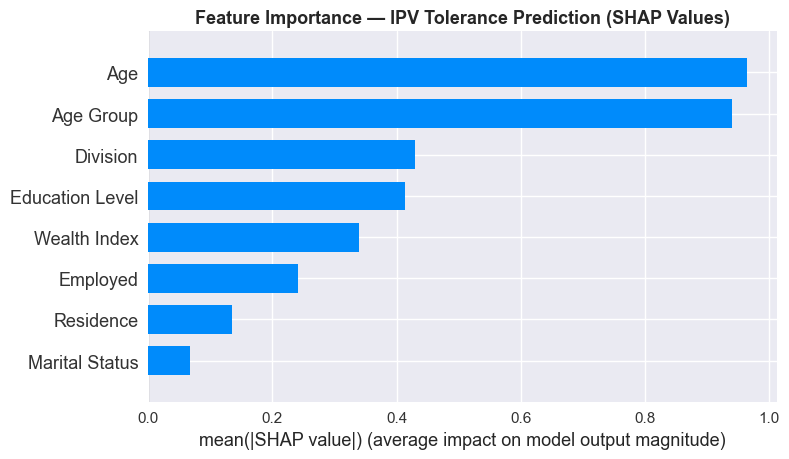

SHAP analysis complete!


In [21]:
import shap

print("Running SHAP analysis (XGBoost)...")

# Use a sample of 500 rows for speed
X_test_sample = X_test.sample(500, random_state=42)

# XGBoost SHAP
explainer = shap.TreeExplainer(results['XGBoost']['model'])
shap_values = explainer.shap_values(X_test_sample)

# Rename columns for display
feature_names = {
    'v012': 'Age',
    'v024': 'Division',
    'v025': 'Residence',
    'v106': 'Education Level',
    'v190': 'Wealth Index',
    'v714': 'Employed',
    'v501': 'Marital Status',
    'age_group_num': 'Age Group'
}
X_test_labeled = X_test_sample.rename(columns=feature_names)

# Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_labeled, plot_type="bar", show=False)
plt.title("Feature Importance — IPV Tolerance Prediction (SHAP Values)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP analysis complete!")

In [22]:
import geopandas as gpd

# Load Bangladesh shapefile
shapefile_path = "data/raw/BDGE81FL/BDGE81FL.shp"
gdf = gpd.read_file(shapefile_path)

print("Shapefile loaded!")
print(f"Shape: {gdf.shape}")
print(f"\nColumns: {gdf.columns.tolist()}")
print(f"\nFirst few rows:")
gdf.head()

Shapefile loaded!
Shape: (674, 21)

Columns: ['DHSID', 'DHSCC', 'DHSYEAR', 'DHSCLUST', 'CCFIPS', 'ADM1FIPS', 'ADM1FIPSNA', 'ADM1SALBNA', 'ADM1SALBCO', 'ADM1DHS', 'ADM1NAME', 'DHSREGCO', 'DHSREGNA', 'SOURCE', 'URBAN_RURA', 'LATNUM', 'LONGNUM', 'ALT_GPS', 'ALT_DEM', 'DATUM', 'geometry']

First few rows:


,DHSID,DHSCC,DHSYEAR,DHSCLUST,CCFIPS,ADM1FIPS,ADM1FIPSNA,ADM1SALBNA,ADM1SALBCO,ADM1DHS,ADM1NAME,DHSREGCO,DHSREGNA,SOURCE,URBAN_RURA,LATNUM,LONGNUM,ALT_GPS,ALT_DEM,DATUM,geometry
0,BD202200000001,BD,2022.0,1.0,BG,NULL,NULL,NULL,NULL,1.0,Barishal,1.0,Barishal,GPS,U,22.717315,90.373835,9999.0,9.0,WGS84,POINT (90.37384 22.71731)
1,BD202200000002,BD,2022.0,2.0,BG,NULL,NULL,NULL,NULL,1.0,Barishal,1.0,Barishal,GPS,U,22.717246,90.382553,9999.0,7.0,WGS84,POINT (90.38255 22.71725)
2,BD202200000003,BD,2022.0,3.0,BG,NULL,NULL,NULL,NULL,1.0,Barishal,1.0,Barishal,GPS,U,22.713827,90.383011,9999.0,8.0,WGS84,POINT (90.38301 22.71383)
3,BD202200000004,BD,2022.0,4.0,BG,NULL,NULL,NULL,NULL,1.0,Barishal,1.0,Barishal,GPS,U,22.698693,90.368405,9999.0,12.0,WGS84,POINT (90.36841 22.69869)
4,BD202200000005,BD,2022.0,5.0,BG,NULL,NULL,NULL,NULL,1.0,Barishal,1.0,Barishal,GPS,U,22.692715,90.366816,9999.0,9.0,WGS84,POINT (90.36682 22.69272)


In [25]:
import requests

# Try different source
url = "https://raw.githubusercontent.com/datasets/geo-boundaries-world-110m/master/countries.geojson"

# Use GADM direct download instead
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_BGD_1.json"

print("Downloading Bangladesh division boundaries...")
response = requests.get(url, timeout=30)
print(f"Status: {response.status_code}")
print(f"Content size: {len(response.content)} bytes")

if response.status_code == 200:
    with open("data/raw/bangladesh_divisions.geojson", "wb") as f:
        f.write(response.content)
    print("Downloaded!")
    
    bd_divisions = gpd.read_file("data/raw/bangladesh_divisions.geojson")
    print(f"Divisions found: {bd_divisions.shape[0]}")
    print(bd_divisions['NAME_1'].tolist())
else:
    print(f"Failed: {response.status_code}")

Status: 200
Content size: 307415 bytes
Downloaded!
Divisions found: 8
['Barisal', 'Chittagong', 'Dhaka', 'Khulna', 'Mymensingh', 'Rajshahi', 'Rangpur', 'Sylhet']


IPV Tolerance Rate by Division:
  division_name  ipv_rate  total_women
3        Khulna      16.3         2566
6       Rangpur      15.6         2512
2         Dhaka      15.3         2946
1    Chittagong      12.1         2927
5      Rajshahi      12.1         2122
0       Barisal      11.2         2093
7        Sylhet      10.7         2328
4    Mymensingh       9.6         2112


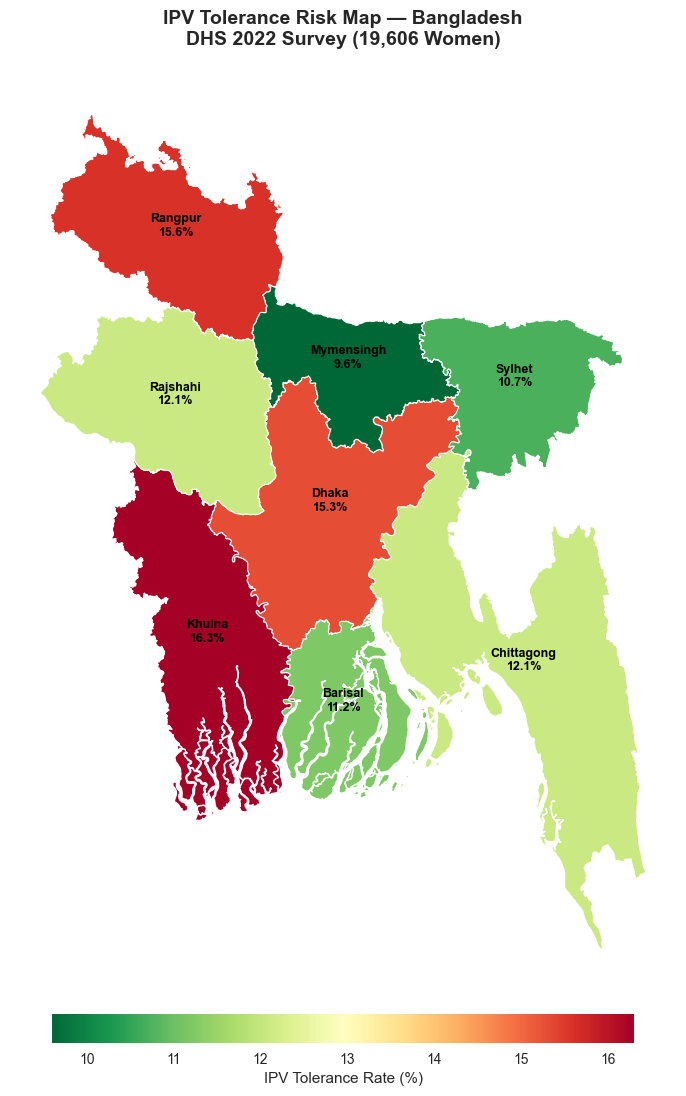

Risk map saved!


In [26]:
# Calculate IPV tolerance rate by division
division_map = {
    1: 'Barisal', 2: 'Chittagong', 3: 'Dhaka', 4: 'Khulna',
    5: 'Rajshahi', 6: 'Rangpur', 7: 'Sylhet', 8: 'Mymensingh'
}

df_clean['division_name'] = df_clean['v024'].map(division_map)

division_risk = df_clean.groupby('division_name')['ipv_tolerance'].agg(
    ipv_rate=lambda x: round(x.mean() * 100, 1),
    total_women='count'
).reset_index()

print("IPV Tolerance Rate by Division:")
print(division_risk.sort_values('ipv_rate', ascending=False))

# Merge with geodataframe
bd_divisions['NAME_1'] = bd_divisions['NAME_1'].replace({'Barisal': 'Barisal'})
gdf_merged = bd_divisions.merge(division_risk, left_on='NAME_1', right_on='division_name')

# Plot choropleth map
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

gdf_merged.plot(
    column='ipv_rate',
    ax=ax,
    legend=True,
    cmap='RdYlGn_r',
    legend_kwds={
        'label': 'IPV Tolerance Rate (%)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02
    },
    edgecolor='white',
    linewidth=0.8
)

# Add division labels
for idx, row in gdf_merged.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        f"{row['NAME_1']}\n{row['ipv_rate']}%",
        xy=(centroid.x, centroid.y),
        fontsize=9,
        fontweight='bold',
        ha='center',
        color='black'
    )

ax.set_title(
    'IPV Tolerance Risk Map — Bangladesh\nDHS 2022 Survey (19,606 Women)',
    fontsize=14, fontweight='bold', pad=20
)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('reports/figures/bangladesh_ipv_risk_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Risk map saved!")

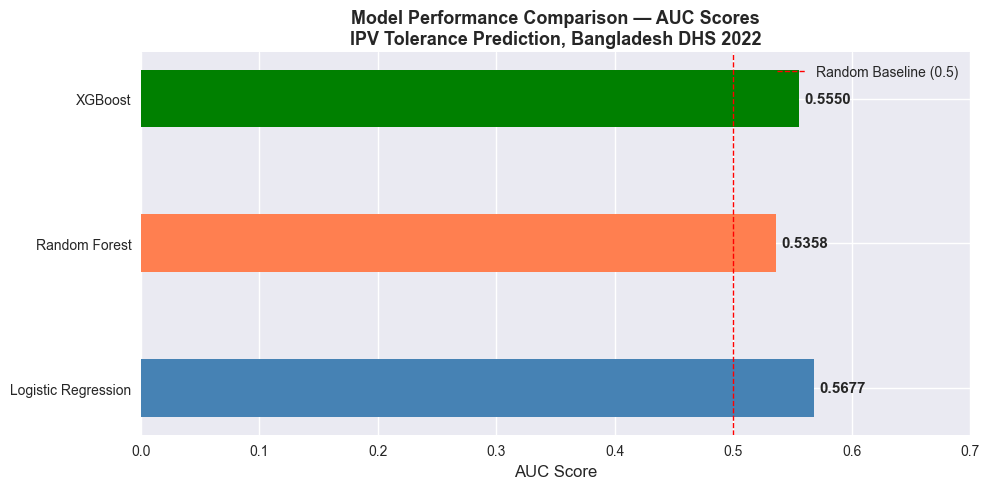

Model comparison chart saved!


In [27]:
# Model Comparison Chart
model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
auc_scores = [results[m]['auc'] for m in model_names]
colors = ['steelblue', 'coral', 'green']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(model_names, auc_scores, color=colors, height=0.4)

# Add value labels
for bar, score in zip(bars, auc_scores):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontweight='bold', fontsize=11)

ax.set_xlim(0, 0.7)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1, label='Random Baseline (0.5)')
ax.set_xlabel('AUC Score', fontsize=12)
ax.set_title('Model Performance Comparison — AUC Scores\nIPV Tolerance Prediction, Bangladesh DHS 2022',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('reports/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison chart saved!")

In [29]:
print("=" * 60)
print("   PROJECT SUMMARY — VAW ANALYTICS SYSTEM — BANGLADESH")
print("=" * 60)

print(f""" DATASET
   Source      : Bangladesh DHS 2022 (BBS + UNFPA)
   Sample size : 19,606 women aged 15-49
   Divisions   : All 8 administrative divisions
   Target      : IPV Tolerance (wife beating acceptance)

 KEY FINDINGS

   Overall IPV Tolerance Rate : 13.1%

   By Division (highest → lowest):
   • Khulna      : 16.3% Highest Risk
   • Rangpur     : 15.6%
   • Dhaka       : 15.3%
   • Chittagong  : 12.1%
   • Rajshahi    : 12.1%
   • Barisal     : 11.2%
   • Sylhet      : 10.7%
   • Mymensingh  :  9.6% Lowest Risk

   By Education:
   • No Education : 17.0% → Higher Education : 7.0%
   • Education reduces IPV tolerance by 59%

   By Wealth:
   • Poorest : 15.9% → Richest : 9.3%
   • Wealth reduces IPV tolerance by 41%

   By Residence:
   • Rural : 14.1% vs Urban : 10.9%

ML MODEL PERFORMANCE
   • Logistic Regression AUC : 0.5677 (best)
   • XGBoost AUC             : 0.5550
   • Random Forest AUC       : 0.5358
   
   Finding: Modest AUC scores indicate socioeconomic
   factors alone have limited predictive power —
   cultural norms play a significant role in IPV tolerance.

SHAP FEATURE IMPORTANCE (top factors)
   1. Age            — strongest predictor
   2. Age Group      — confirms age effect
   3. Division       — regional culture matters
   4. Education      — protective factor
   5. Wealth Index   — protective factor
   6. Employment     — moderate effect
   7. Residence      — urban/rural difference
   8. Marital Status — least predictive
""")
print("=" * 60)
print("Analysis complete!")
print("=" * 60)

   PROJECT SUMMARY — VAW ANALYTICS SYSTEM — BANGLADESH
 DATASET
   Source      : Bangladesh DHS 2022 (BBS + UNFPA)
   Sample size : 19,606 women aged 15-49
   Divisions   : All 8 administrative divisions
   Target      : IPV Tolerance (wife beating acceptance)

 KEY FINDINGS

   Overall IPV Tolerance Rate : 13.1%

   By Division (highest → lowest):
   • Khulna      : 16.3% Highest Risk
   • Rangpur     : 15.6%
   • Dhaka       : 15.3%
   • Chittagong  : 12.1%
   • Rajshahi    : 12.1%
   • Barisal     : 11.2%
   • Sylhet      : 10.7%
   • Mymensingh  :  9.6% Lowest Risk

   By Education:
   • No Education : 17.0% → Higher Education : 7.0%
   • Education reduces IPV tolerance by 59%

   By Wealth:
   • Poorest : 15.9% → Richest : 9.3%
   • Wealth reduces IPV tolerance by 41%

   By Residence:
   • Rural : 14.1% vs Urban : 10.9%

ML MODEL PERFORMANCE
   • Logistic Regression AUC : 0.5677 (best)
   • XGBoost AUC             : 0.5550
   • Random Forest AUC       : 0.5358

   Finding: Modest

In [31]:
for root, dirs, files in os.walk("."):
    dirs[:] = [d for d in dirs if d not in ['venv', '__pycache__', '.ipynb_checkpoints']]
    for file in files:
        print(os.path.join(root, file))

.\README.md
.\VAW_Analytics_Bangladesh_DHS2022.ipynb
.\.git\config
.\.git\description
.\.git\HEAD
.\.git\index
.\.git\packed-refs
.\.git\hooks\applypatch-msg.sample
.\.git\hooks\commit-msg.sample
.\.git\hooks\fsmonitor-watchman.sample
.\.git\hooks\post-update.sample
.\.git\hooks\pre-applypatch.sample
.\.git\hooks\pre-commit.sample
.\.git\hooks\pre-merge-commit.sample
.\.git\hooks\pre-push.sample
.\.git\hooks\pre-rebase.sample
.\.git\hooks\pre-receive.sample
.\.git\hooks\prepare-commit-msg.sample
.\.git\hooks\push-to-checkout.sample
.\.git\hooks\sendemail-validate.sample
.\.git\hooks\update.sample
.\.git\info\exclude
.\.git\logs\HEAD
.\.git\logs\refs\heads\main
.\.git\logs\refs\remotes\origin\HEAD
.\.git\objects\pack\pack-bb8818d1d42a15d7953aa0ec0b8497ee93014657.idx
.\.git\objects\pack\pack-bb8818d1d42a15d7953aa0ec0b8497ee93014657.pack
.\.git\objects\pack\pack-bb8818d1d42a15d7953aa0ec0b8497ee93014657.rev
.\.git\refs\heads\main
.\.git\refs\remotes\origin\HEAD
.\data\raw\bangladesh_divisi